# Testing and Comparing Montbrió-Pazó-Roxin Model Differential Equations Implementations in TVB and VBjax


The differential equations (usually called `dfun` in the implementations) in papers describing neural‑mass models are often long and complicated. As such, they are prone to sign errors and other algebraic slips. Because the variables in the code usually follow standard mathematical notation (viz. TVB, VBjax, Neurolib), a single mistyped character is an easy mistake to make. Their nested derivatives, multiple parameters, and layered terms make it difficult to spot mistakes by eye, and small errors could slip by a regular code review, if it is even done. For this reason, a simple way to write unit tests is useful and could save model developers valuable time.

This notebook/test suite focuses exclusively on unit-testing the `dfun` of the Montbrió-Pazó-Roxin (MPR) model. It provides two ways to test `dfun` correctness depending on the models implementation. It also provides several ways to pick test granularity, based on the users working knowledge of the model.

`dfun` is such an important component of a model, developers often expose it as a separate function. For example, both TVB and VBjax libraries utilize separate `dfun`. If this is the case, you may test it as such, this tutorial provides a guideline on how build a test suite for such a possibility. However, this is not a requirement for successful testing of `dfun`, and you will find a way to test it even if it is not a separate function.

In the case where `dfun` is not a separate function, the requirements are the same as for the all other tutorials in this suite. A chosen ground truth model to compare against, for the model to be able to be initialized with any relevant initial conditions and parameters, and for it to be able to do one step of Euler integration.

The first step is identifying the relevant model parameters. For TVB and VBjax, most parameters map directly between the two implementations. However, the `Gamma` parameter in TVB is unused and can be disregarded.

For parameters that are relevant to the computation but only appear in one model but not the other, choose values that allow for consistent mapping between the models. (Good candidates include powers of ten for scaling, zero for additive terms, or identical "magic constants".)

In this case, `Gamma` parameter of the TVB implementation is irrelevant, and the default parameter values match between TVB and VBjax (`mpr_default_theta`), so these are used as the starting point.

In [1]:
from vbjax import mpr_default_theta

mpr_default_theta

c[vbjax] ███▒▒▒▒▒▒▒ loading
c[vbjax] (ﾉ☉ヮ⚆)ﾉ ⌒*:･ﾟ✧ can haz 12 cores
c[vbjax] ò_ô shtns is not available


c[vbjax] ᕕ(ᐛ)ᕗ ready


MPRTheta(tau=1.0, I=0.0, Delta=1.0, J=15.0, eta=-5.0, cr=1.0, cv=0.0)

## Choosing Test Values for `r` and `V`

Rather than manually selecting points on the phase plane—which is both time-consuming and error-prone, we chose a sufficient number of random points.

These are stored in `test_data/random_points0.0_2.0_-2.0_1.5.npz`, with `r` values in the range [0, 2] and `V` in [-2, 1.5]. The relevant parts of the phase plane can move away from these values of state variables, so for this purpose we've implemented a sanity check functionality.

The points are generated once per `(r, V)` range and stored for reproducibility. This is necessary because NumPy’s RNG does not guarantee cross-version stability—even with seeding.


/home/dj/miniconda3/envs/diplomka/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)


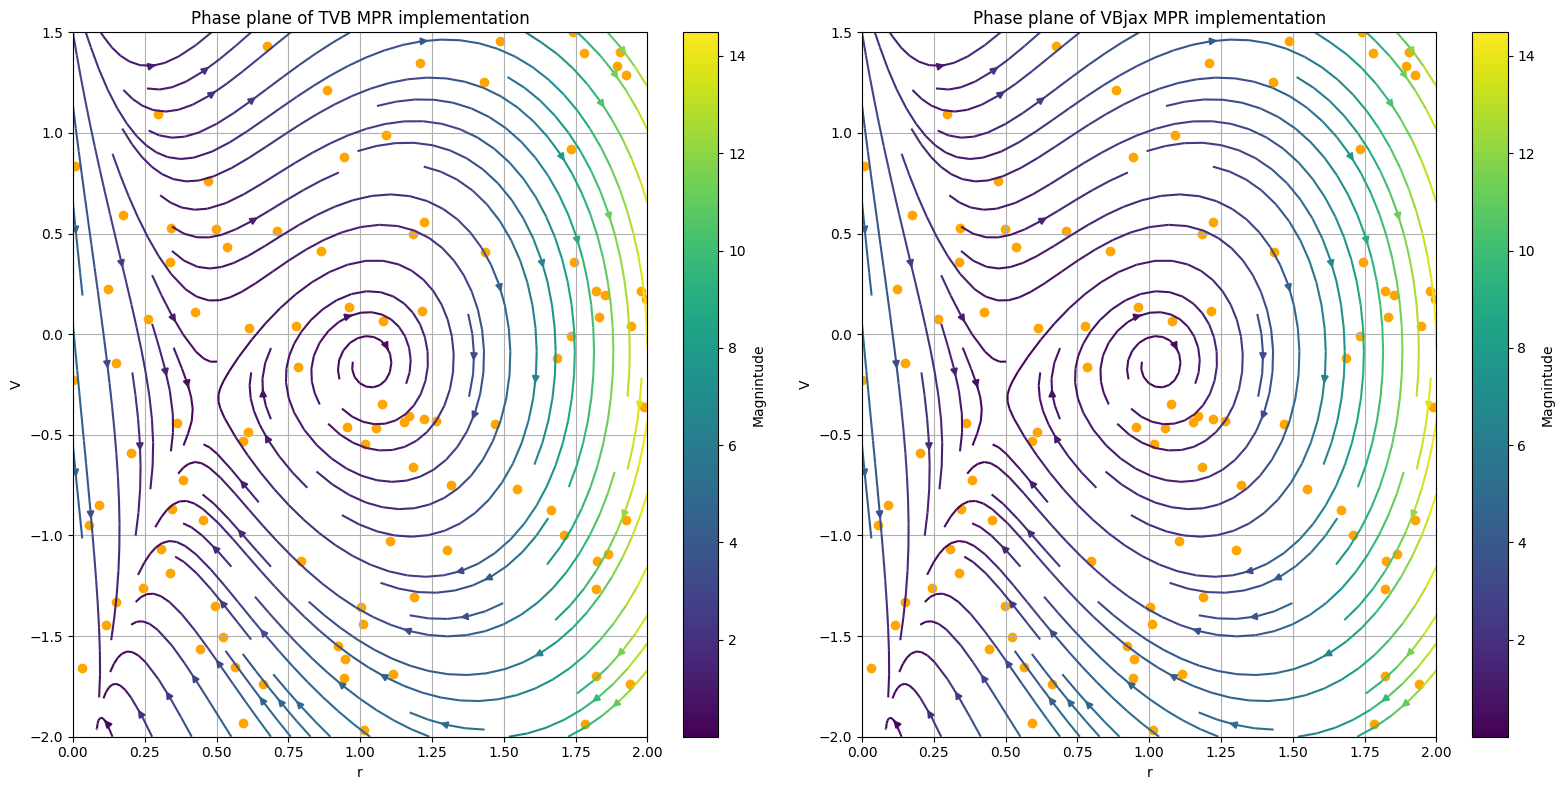

In [2]:
from mpr_tvb_vbjax_sanity_check import plot_phase_plane_and_random_points
from mpr_tvb_vbjax_test_parameters import default_values

plot_phase_plane_and_random_points(default_values.iloc[0])

## Defining Test Cases

Next, we define our parameter sets. There are two approaches:
1. **Target key regions of the bifurcation diagram**
2. **Use brute force sampling across the parameter space, one parameter at a time**

The recommended approach is to use both. Option #1 as it is most likely to find issues with the functions, as it expects predictable, yet different behavior of the function. There is a general problem with testing of these functions, which is that the regions that are tested need to be vetted, so that we're not looking in the wrong place. Option #1 circumvents this issue by having few enough test cases that manual checking is possible. Option #2 simply ignores this, in favor of having lots of test cases.

As for the one parameter at a time part of option two, this comes from the pragmatic view of the problem as simply a parametrized f(x). If there is a difference in f(x) and f'(x), changing multiple parameters at the same time (and with sufficient sampling density) should reveal this difference just the same as changing only one.

In [16]:
import numpy as np

# Option 1

_test_cases = [{"eta": [-10, -5, -0.001]}]


# Option 2

_test_cases += [
    {"tau": np.linspace(0.001, 15.0, 100).tolist()},
    {"I": np.linspace(-10.0, 10.0, 100).tolist()},
    {"Delta": np.linspace(0.0, 10.0, 100).tolist()},
    {"J": np.linspace(-25.0, 25.0, 100).tolist()},
    {"eta": np.linspace(-10.0, 10.0, 100).tolist()},
    {"cr": np.linspace(0.0, 1.0, 100).tolist()},
    {"cv": np.linspace(0.0, 1.0, 100).tolist()},
]

## Parameter Expansion

Each test case is represented as a row in a Pandas DataFrame.

- The first few columns contain model parameters.
- `_low` and `_high` define the `(r, V)` sampling range for the test case.
- `linspace_size` specifies how many points to generate in that range.

This structure allows for different sampling regions depending on the parameter set.


In [17]:
from mpr_tvb_vbjax_test_parameters import _expand_test_cases

test_cases = _expand_test_cases(_test_cases)
test_cases

,tau,I,Delta,J,eta,cr,cv,r_low,r_high,V_low,V_high,linspace_size
0,1.000000,0.0,1.0,15.0,-10.000,1.0,0.000000,0.0,2.0,-2.0,1.5,100.0
1,1.000000,0.0,1.0,15.0,-5.000,1.0,0.000000,0.0,2.0,-2.0,1.5,100.0
2,1.000000,0.0,1.0,15.0,-0.001,1.0,0.000000,0.0,2.0,-2.0,1.5,100.0
3,0.001000,0.0,1.0,15.0,-5.000,1.0,0.000000,0.0,2.0,-2.0,1.5,100.0
4,0.152505,0.0,1.0,15.0,-5.000,1.0,0.000000,0.0,2.0,-2.0,1.5,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
698,1.000000,0.0,1.0,15.0,-5.000,1.0,0.959596,0.0,2.0,-2.0,1.5,100.0
699,1.000000,0.0,1.0,15.0,-5.000,1.0,0.969697,0.0,2.0,-2.0,1.5,100.0
700,1.000000,0.0,1.0,15.0,-5.000,1.0,0.979798,0.0,2.0,-2.0,1.5,100.0
701,1.000000,0.0,1.0,15.0,-5.000,1.0,0.989899,0.0,2.0,-2.0,1.5,100.0


## Compatibility Layer

Since our test case format isn't directly compatible with either model, we build a translation layer to map our test case data into the input formats expected by TVB and VBjax implementations.


In [18]:
from typing import List
from numpy import typing as npt
import numpy as np
import pandas as pd
from tvb.simulator.models.infinite_theta import MontbrioPazoRoxin
from mpr_tvb_vbjax_test_functions import load_or_generate_data_for_testcase
from mpr_tvb_vbjax_test_parameters import coupling_
from vbjax import MPRTheta, mpr_dfun

parameter_list = ["tau", "I", "Delta", "J", "eta", "cr", "cv"]


def run_tvb_implementation(test_case, test_data: List[npt.NDArray]):

    # Extract parameters for the model from the test case
    parameters_only = test_case[parameter_list]

    # Transform parameters to a data format acceptable for the model
    param_dict = {k: np.array([v]) for k, v in parameters_only.items()}

    # Run the dfun
    return MontbrioPazoRoxin(**param_dict, Gamma=np.r_[0.0]).dfun(
        test_data,
        coupling=coupling_,
    )


def run_vbjax_implementation(test_case, test_data: List[npt.NDArray]):

    # Extract parameters for the model from the test case
    parameters_only = test_case[parameter_list]

    # Transform parameters to a data format acceptable for the model
    params_as_mprtheta = MPRTheta(**parameters_only.to_dict())

    # Run the dfun
    return mpr_dfun(
        test_data,
        c=coupling_,
        p=params_as_mprtheta,
    )


# Convenience wrapper for running both dfuncs on the same dataset with the same parameters
def run_test(test_case: pd.Series):

    test_data = load_or_generate_data_for_testcase(test_case)

    return (
        run_tvb_implementation(test_case, test_data),
        run_vbjax_implementation(test_case, test_data),
        # Here you could place more implementations in case you're testing multiple simulators
    )

## On the Pitfalls of Shared Sampling Ranges

As shown below, using identical `(r, V)` ranges across all test cases may result in test outcomes from `dfun` regions where nothing of interest happens (e.g., false positives or negatives). It’s important to tailor the sampling region to the expected dynamics. As of now, we're unable to do this automatically, which is partly why we chose to go with a lower number of parameter combinations.


tau                1.0
I                  0.0
Delta              1.0
J                 15.0
eta                -10
cr                 1.0
cv                 0.0
r_low              0.0
r_high             2.0
V_low             -2.0
V_high             1.5
linspace_size    100.0
Name: 0, dtype: object


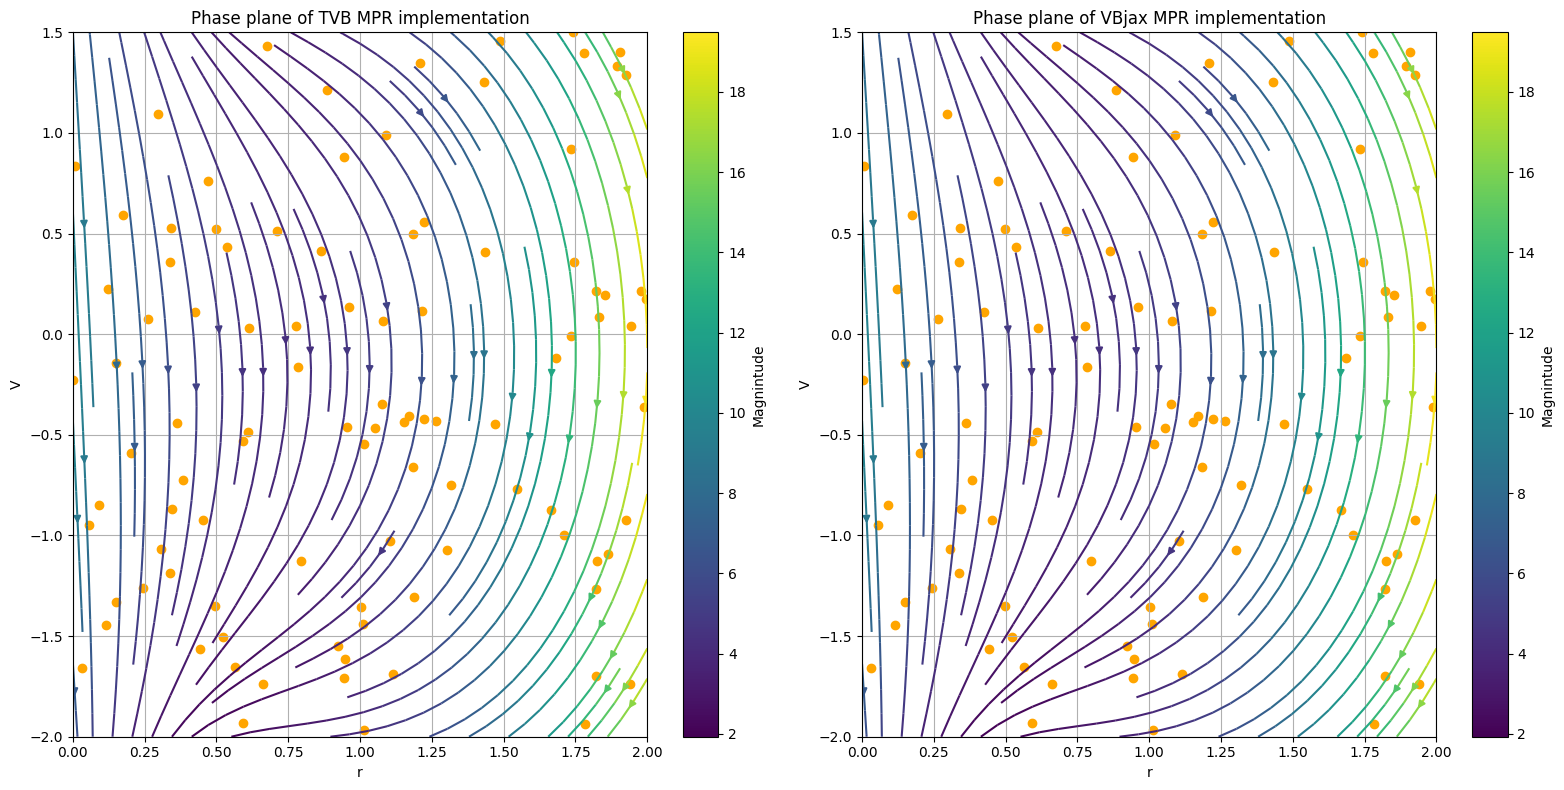

In [13]:
current_test_case = test_cases.iloc[0]

print(current_test_case)

plot_phase_plane_and_random_points(current_test_case)

## Pytest: Minimal and Extended Testing

The following cells contain two `pytest`-based test setups:

1. A **minimal** version.
2. A **full** version that logs test results when running all tests, and logs more data when specific tests are re-run.

These are provided for educational use. If you wish to modify them, make changes directly in the test scripts.


In [ ]:
import numpy as np
import pytest

from mpr_tvb_vbjax_test_functions import run_test
from mpr_tvb_vbjax_test_parameters import test_parameters

indices, rows = zip(*test_parameters.iterrows())


@pytest.mark.parametrize("row", rows, ids=indices)
def test_one_case(row):
    test_results = run_test(row)
    assert np.allclose(*test_results)

In [ ]:
import json
import os

import numpy as np
import pytest
from mpr_tvb_vbjax_test_functions import run_test

from mpr_tvb_vbjax_test_parameters import test_parameters

indices, rows = zip(*test_parameters.iterrows())
results = []


@pytest.fixture(scope="session")
def is_single_test(pytestconfig):
    # All command line args after 'pytest'
    args = pytestconfig.args  # list of CLI args, e.g. ['test.py::test_one_case[6]']
    # If exactly one argument that contains a nodeid with param, consider it a single test run
    single_test = len(args) == 1 and ("::" in args[0])
    return single_test


@pytest.mark.parametrize("row", rows, ids=indices)
def test_one_case(row, is_single_test, request):
    test_results = run_test(row)
    try:
        assert np.allclose(*test_results)
        results.append("1")
    except AssertionError as identifier:
        results.append("0")
        if not is_single_test:
            raise identifier
        call_id = request.node.callspec.id
        with open(f"results/failed_test_id_{call_id}.json", "w", encoding="utf-8") as file:
            json.dump(
                {
                    "test_case": row.to_dict(),
                    "test_results": {
                        # Rename these as necessary
                        "tvb": test_results[0].tolist(),
                        "vbjax": test_results[1].tolist(),
                        # You can also add more if you alter run_test
                    },
                },
                file,
            )
        raise identifier


@pytest.fixture(scope="session", autouse=True)
def write_results(is_single_test):
    yield 0
    if is_single_test:
        return
    with open(f"results/all_test_results.csv", "w", encoding="utf-8") as file:
        file.write("test_results" + os.linesep)
        print(results)
        file.writelines(os.linesep.join(results))

## Running the Test Suite

Here you can run the `pytest` suite directly from this notebook.

Note: This executes tests as defined in the scripts and **will not reflect** changes made interactively in the notebook.


In [9]:
! pytest mpr_tvb_vbjax_test.py

/home/dj/miniconda3/envs/diplomka/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


============================= test session starts ==============================
platform linux -- Python 3.11.13, pytest-8.4.1, pluggy-1.6.0
rootdir: /home/dj/diplomka
collected 6 items                                                              

mpr_tvb_vbjax_test.py ......                                             [100%]

=============================== warnings summary ===============================
../miniconda3/envs/diplomka/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60
  /home/dj/miniconda3/envs/diplomka/lib/python3.11/site-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
    warnings.warn(msg)

../miniconda3/envs/diplomka/lib/python3.11/site-packages/vbjax/sparse.py:56
  /home/dj/miniconda3/envs/diplomka/lib/python3.11/site-packages/vbjax/sparse.py:56: DeprecationWarning: jax.sharding.PositionalSharding is deprecated. Use jax.NamedSharding instead.
    sharding: jax

Ak nemame dfun, mozme spravit jeden krok simulacie